# Per-line ResNet50 models - results

**Step 4, 2026-09-17.** Five models, one per production line, each trained on its own line's train
half and scored on held-out pictures from the same line.

| Setting | Value |
|---|---|
| Model | ResNet50, ImageNet weights, base fully trainable |
| Head | Global average pooling, batch norm, dense 1024, dropout 0.3, softmax |
| Optimizer | SGD, learning rate 1e-4, momentum 0.9, Nesterov |
| Loss | sparse categorical crossentropy |
| Epochs / batch / seed | 50 / 4 / 42 |
| Input | the raw 2448x2048 frame resized to 224x224, no crop |
| Split | exact-count stratified inside each class inside each line, seed 42, 70:30 |
| Data | 8,402 pictures, 5,875 train, 2,527 test, 87 class-line cells |
| Total training time | 52.5 minutes on one A100 for all five lines |

The model, optimizer, loss, metric set and seed are the same code as the 2026-09-15
six-architecture run. Three things differ on purpose: batch 4 instead of 8, the raw frame instead
of the fixed-size crop, and one model per line instead of one pooled model. Those differences mean
these numbers should not be compared with that run's numbers.

## The five models

| Line | Train | Test | Classes | Accuracy | Macro F1 | Weighted F1 | Train minutes |
|---|---|---|---|---|---|---|---|
| L24 | 1993 | 858 | 19 | 89.39% | 65.20% | 89.10% | 20.6 |
| L25 | 663 | 287 | 17 | 89.90% | 57.17% | 88.52% | 6.9 |
| L26 | 853 | 365 | 17 | 90.41% | 57.05% | 88.82% | 8.9 |
| L27 | 955 | 409 | 15 | 86.80% | 60.37% | 86.11% | 10.0 |
| L31 | 1411 | 608 | 19 | 90.62% | 45.62% | 89.70% | 14.6 |

Accuracy and weighted F1 are pooled over the 2,527 test pictures across the five models. Macro F1
is the mean of the five per-line macro figures; the five class lists differ, so there is no single
macro quantity across them.

In [ ]:
import json, os
root = 'runs/cnn/lines'
for line in ['L24', 'L25', 'L26', 'L27', 'L31']:
    m = json.load(open(os.path.join(root, line, 'epochs_50', 'metrics.json')))
    print('{0}: acc {1:.2%}  macro F1 {2:.2%}  weighted F1 {3:.2%}  test {4}'.format(
        line, m['overall_accuracy'], m['macro']['f1'], m['weighted']['f1'], m['num_test_images']))

## What the numbers actually say

**1. The score tracks how many test pictures a class has, not which line it came from.**

| Test pictures in the cell | Cells | Mean F1 | Median F1 | Lowest | Highest | Cells at zero F1 |
|---|---|---|---|---|---|---|
| 1 to 4 test pictures | 35 | 26.83% | 0.00% | 0.00% | 100.00% | 23 |
| 5 to 24 test pictures | 28 | 70.07% | 87.10% | 0.00% | 100.00% | 1 |
| 25 or more test pictures | 24 | 85.50% | 91.11% | 47.89% | 100.00% | 0 |

A cell with four or fewer test pictures has a median F1 of zero. Every cell with 25 or more test
pictures scores above zero, and 24 of them average 83.52 percent. So a low number in a thin cell
measures the cell, not the model and not the line.

**2. The same class produces wildly different scores on different lines, and the swing follows the
cell size.**

| Class | L24 | L25 | L26 | L27 | L31 |
|---|---|---|---|---|---|
| Lens Off Center | 87% (59) | 0% (2) | 100% (2) | 14% (8) | 50% (6) |
| View Obstructed | 0% (6) | 91% (5) | 33% (10) | 100% (3) | 95% (11) |
| Missing Lens | 99% (55) | 67% (2) | 0% (1) | 96% (24) | 100% (15) |
| Bubble Cluster | 18% (5) | 0% (1) | 100% (1) | 0% (3) | 0% (1) |
| Multiple Lenses | 89% (101) | 95% (83) | 98% (202) | 100% (16) | 93% (29) |
| Missing Primary Package | 100% (344) | 100% (57) | 80% (2) | 100% (4) | 100% (22) |

The numbers in brackets are test pictures in that cell. Every large class repeats across lines;
every small class does not.

**3. Most errors sit inside one family, and a documented confusion shows up.**

Across the five models 309 of the 2,527 test pictures are misclassified, 12.2 percent. The largest
single directions are:

| True class | Predicted as | Test pictures |
|---|---|---|
| Foreign Matter | Fiber | 66 |
| Fiber | Foreign Matter | 21 |
| Extraneous Polymer | Fiber | 20 |
| Extraneous Polymer | Foreign Matter | 17 |
| Lens Off Center | Low Dose Obstructing Region of Interest | 14 |
| Foreign Matter | Extraneous Polymer | 10 |
| Fiber | Extraneous Polymer | 8 |
| View Obstructed | Bubble | 8 |

Foreign Matter, Fiber and Extraneous Polymer account for 142 of the 309 errors, 46 percent, and they
keep taking each other's labels. The dataset does not separate them cleanly either: 33 pictures carry
both Extraneous Polymer and Fiber as labels and our pooling rule gives each one label. The client's
naming document states that Lens Off Center is commonly confused with Low Dose, and that is exactly
where 14 of the errors land.

One line-specific example: on L24 all 6 of View Obstructed's test pictures were called HEMA
Obstruction, on the one line where HEMA Obstruction is a heavyweight class. Across all five lines the
class's largest confusion is Bubble, 8 pictures.

**4. The classes that hold up are the structural ones; the ones that fail are small objects.**

Missing Primary Package, Cavity Off Center, Package Misalignment and Multiple Lenses score 80 to 100
percent nearly everywhere. Fiber, Extraneous Polymer, Bubble Cluster, Bubble Irregular and the
single-picture classes fail. That is what a 2448-wide frame squeezed to 224x224 does to a defect a
few tens of pixels across, and it is the visible cost of dropping the crop step.

## L24

1993 train / 858 test, 19 classes, accuracy 89.39%, macro F1 65.20%, weighted F1 89.10%, 20.6 minutes.

| Class | Test pictures | Precision | Recall | F1 |
|---|---|---|---|---|
| Bubble | 25 | 76.00% | 76.00% | 76.00% |
| Bubble Cluster | 5 | 20.00% | 20.00% | 20.00% |
| Bubble Irregular | 4 | 100.00% | 50.00% | 66.67% |
| Bubble On Edge | 1 | 0.00% | 0.00% | 0.00% |
| Cavity Off Center | 28 | 100.00% | 96.43% | 98.18% |
| Dirty Camera | 8 | 77.78% | 87.50% | 82.35% |
| Extraneous Polymer | 18 | 37.50% | 16.67% | 23.08% |
| Fiber | 26 | 37.78% | 65.38% | 47.89% |
| Foreign Matter | 86 | 75.00% | 73.26% | 74.12% |
| HEMA Fragment | 2 | 0.00% | 0.00% | 0.00% |
| HEMA Obstruction | 45 | 89.36% | 93.33% | 91.30% |
| Lens Off Center | 59 | 93.10% | 91.53% | 92.31% |
| Low Dose Obstructing Region of Interest | 32 | 88.89% | 75.00% | 81.36% |
| Missing Lens | 55 | 100.00% | 98.18% | 99.08% |
| Missing Primary Package | 344 | 100.00% | 99.71% | 99.85% |
| Multiple Lenses | 101 | 88.79% | 94.06% | 91.35% |
| Package Misalignment | 10 | 90.91% | 100.00% | 95.24% |
| View Obstructed | 6 | 100.00% | 100.00% | 100.00% |
| Wet Package | 3 | 0.00% | 0.00% | 0.00% |


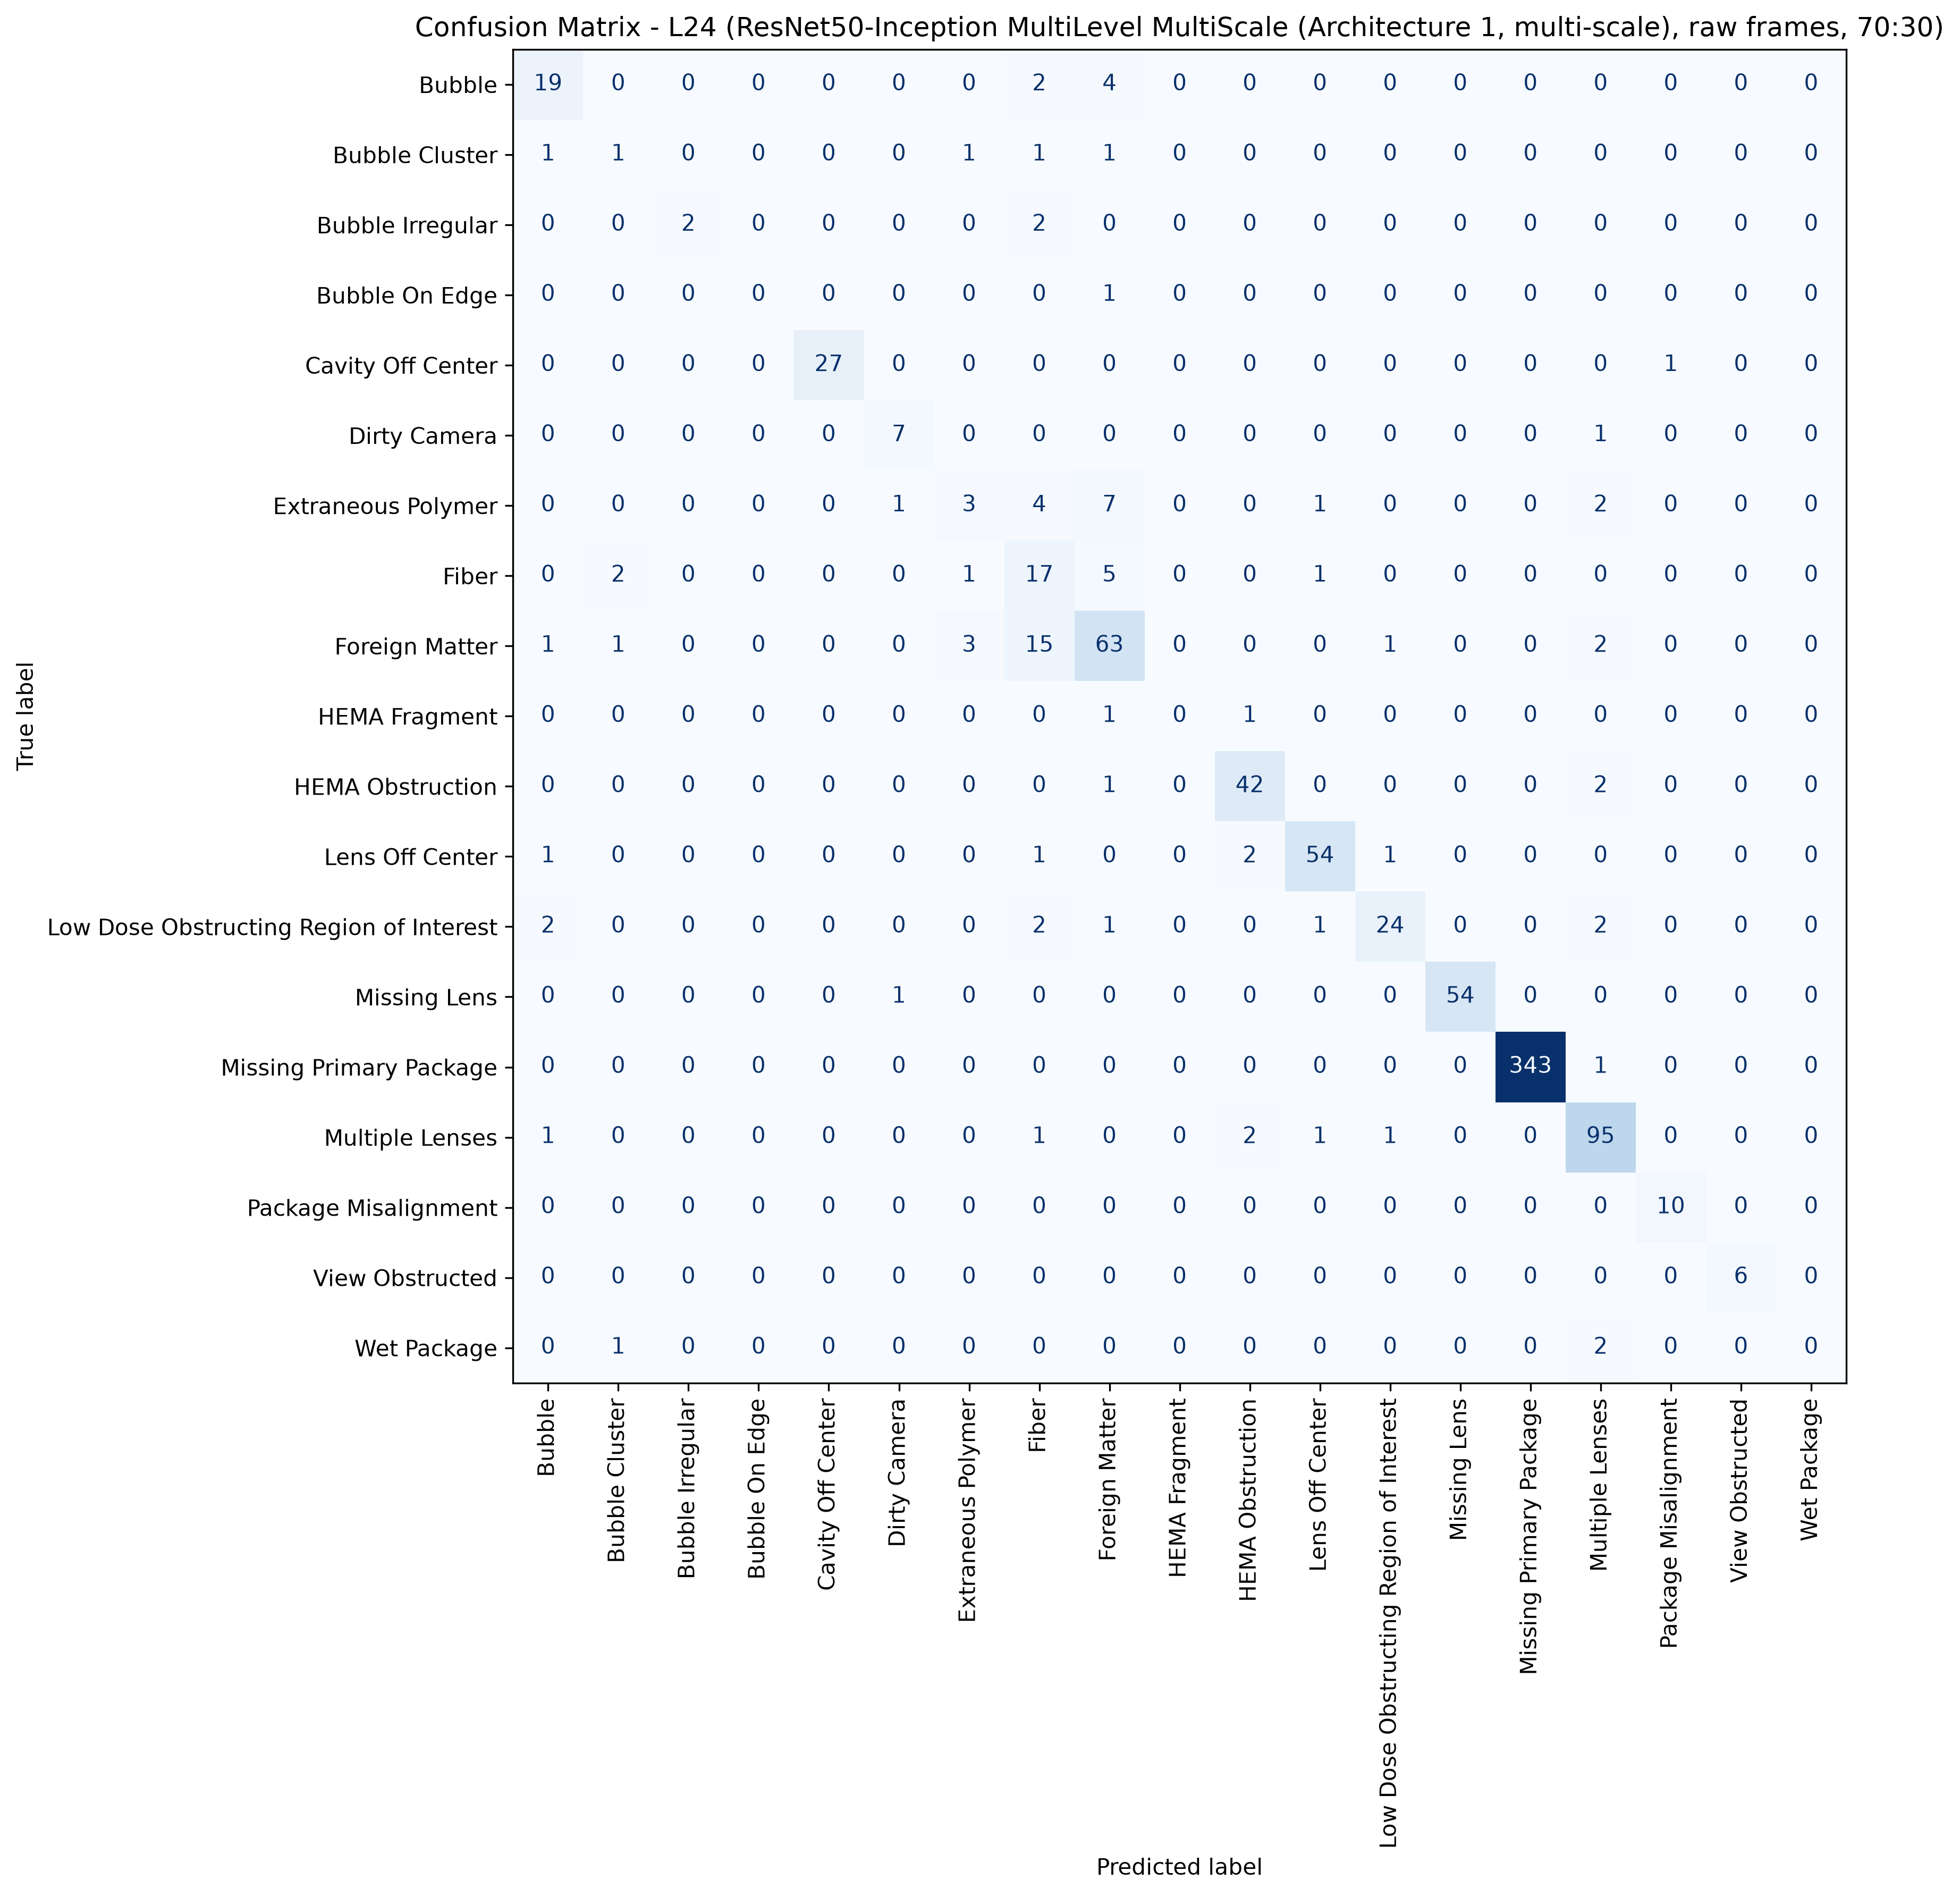


## L25

663 train / 287 test, 17 classes, accuracy 89.90%, macro F1 57.17%, weighted F1 88.52%, 6.9 minutes.

| Class | Test pictures | Precision | Recall | F1 |
|---|---|---|---|---|
| Bubble | 5 | 66.67% | 40.00% | 50.00% |
| Bubble Cluster | 1 | 0.00% | 0.00% | 0.00% |
| Bubble On Edge | 1 | 0.00% | 0.00% | 0.00% |
| Cavity Off Center | 12 | 100.00% | 100.00% | 100.00% |
| Dirty Strobe | 4 | 66.67% | 100.00% | 80.00% |
| Extraneous Polymer | 3 | 0.00% | 0.00% | 0.00% |
| Fiber | 11 | 56.25% | 81.82% | 66.67% |
| Foreign Matter | 25 | 71.43% | 80.00% | 75.47% |
| HEMA Obstruction | 5 | 100.00% | 40.00% | 57.14% |
| Lens Off Center | 2 | 0.00% | 0.00% | 0.00% |
| Low Dose Obstructing Region of Interest | 17 | 92.86% | 76.47% | 83.87% |
| Missing Lens | 2 | 100.00% | 50.00% | 66.67% |
| Missing Primary Package | 57 | 100.00% | 100.00% | 100.00% |
| Multiple Lenses | 83 | 89.89% | 96.39% | 93.02% |
| Package Misalignment | 53 | 98.15% | 100.00% | 99.07% |
| View Obstructed | 5 | 100.00% | 100.00% | 100.00% |
| Wet Package | 1 | 0.00% | 0.00% | 0.00% |


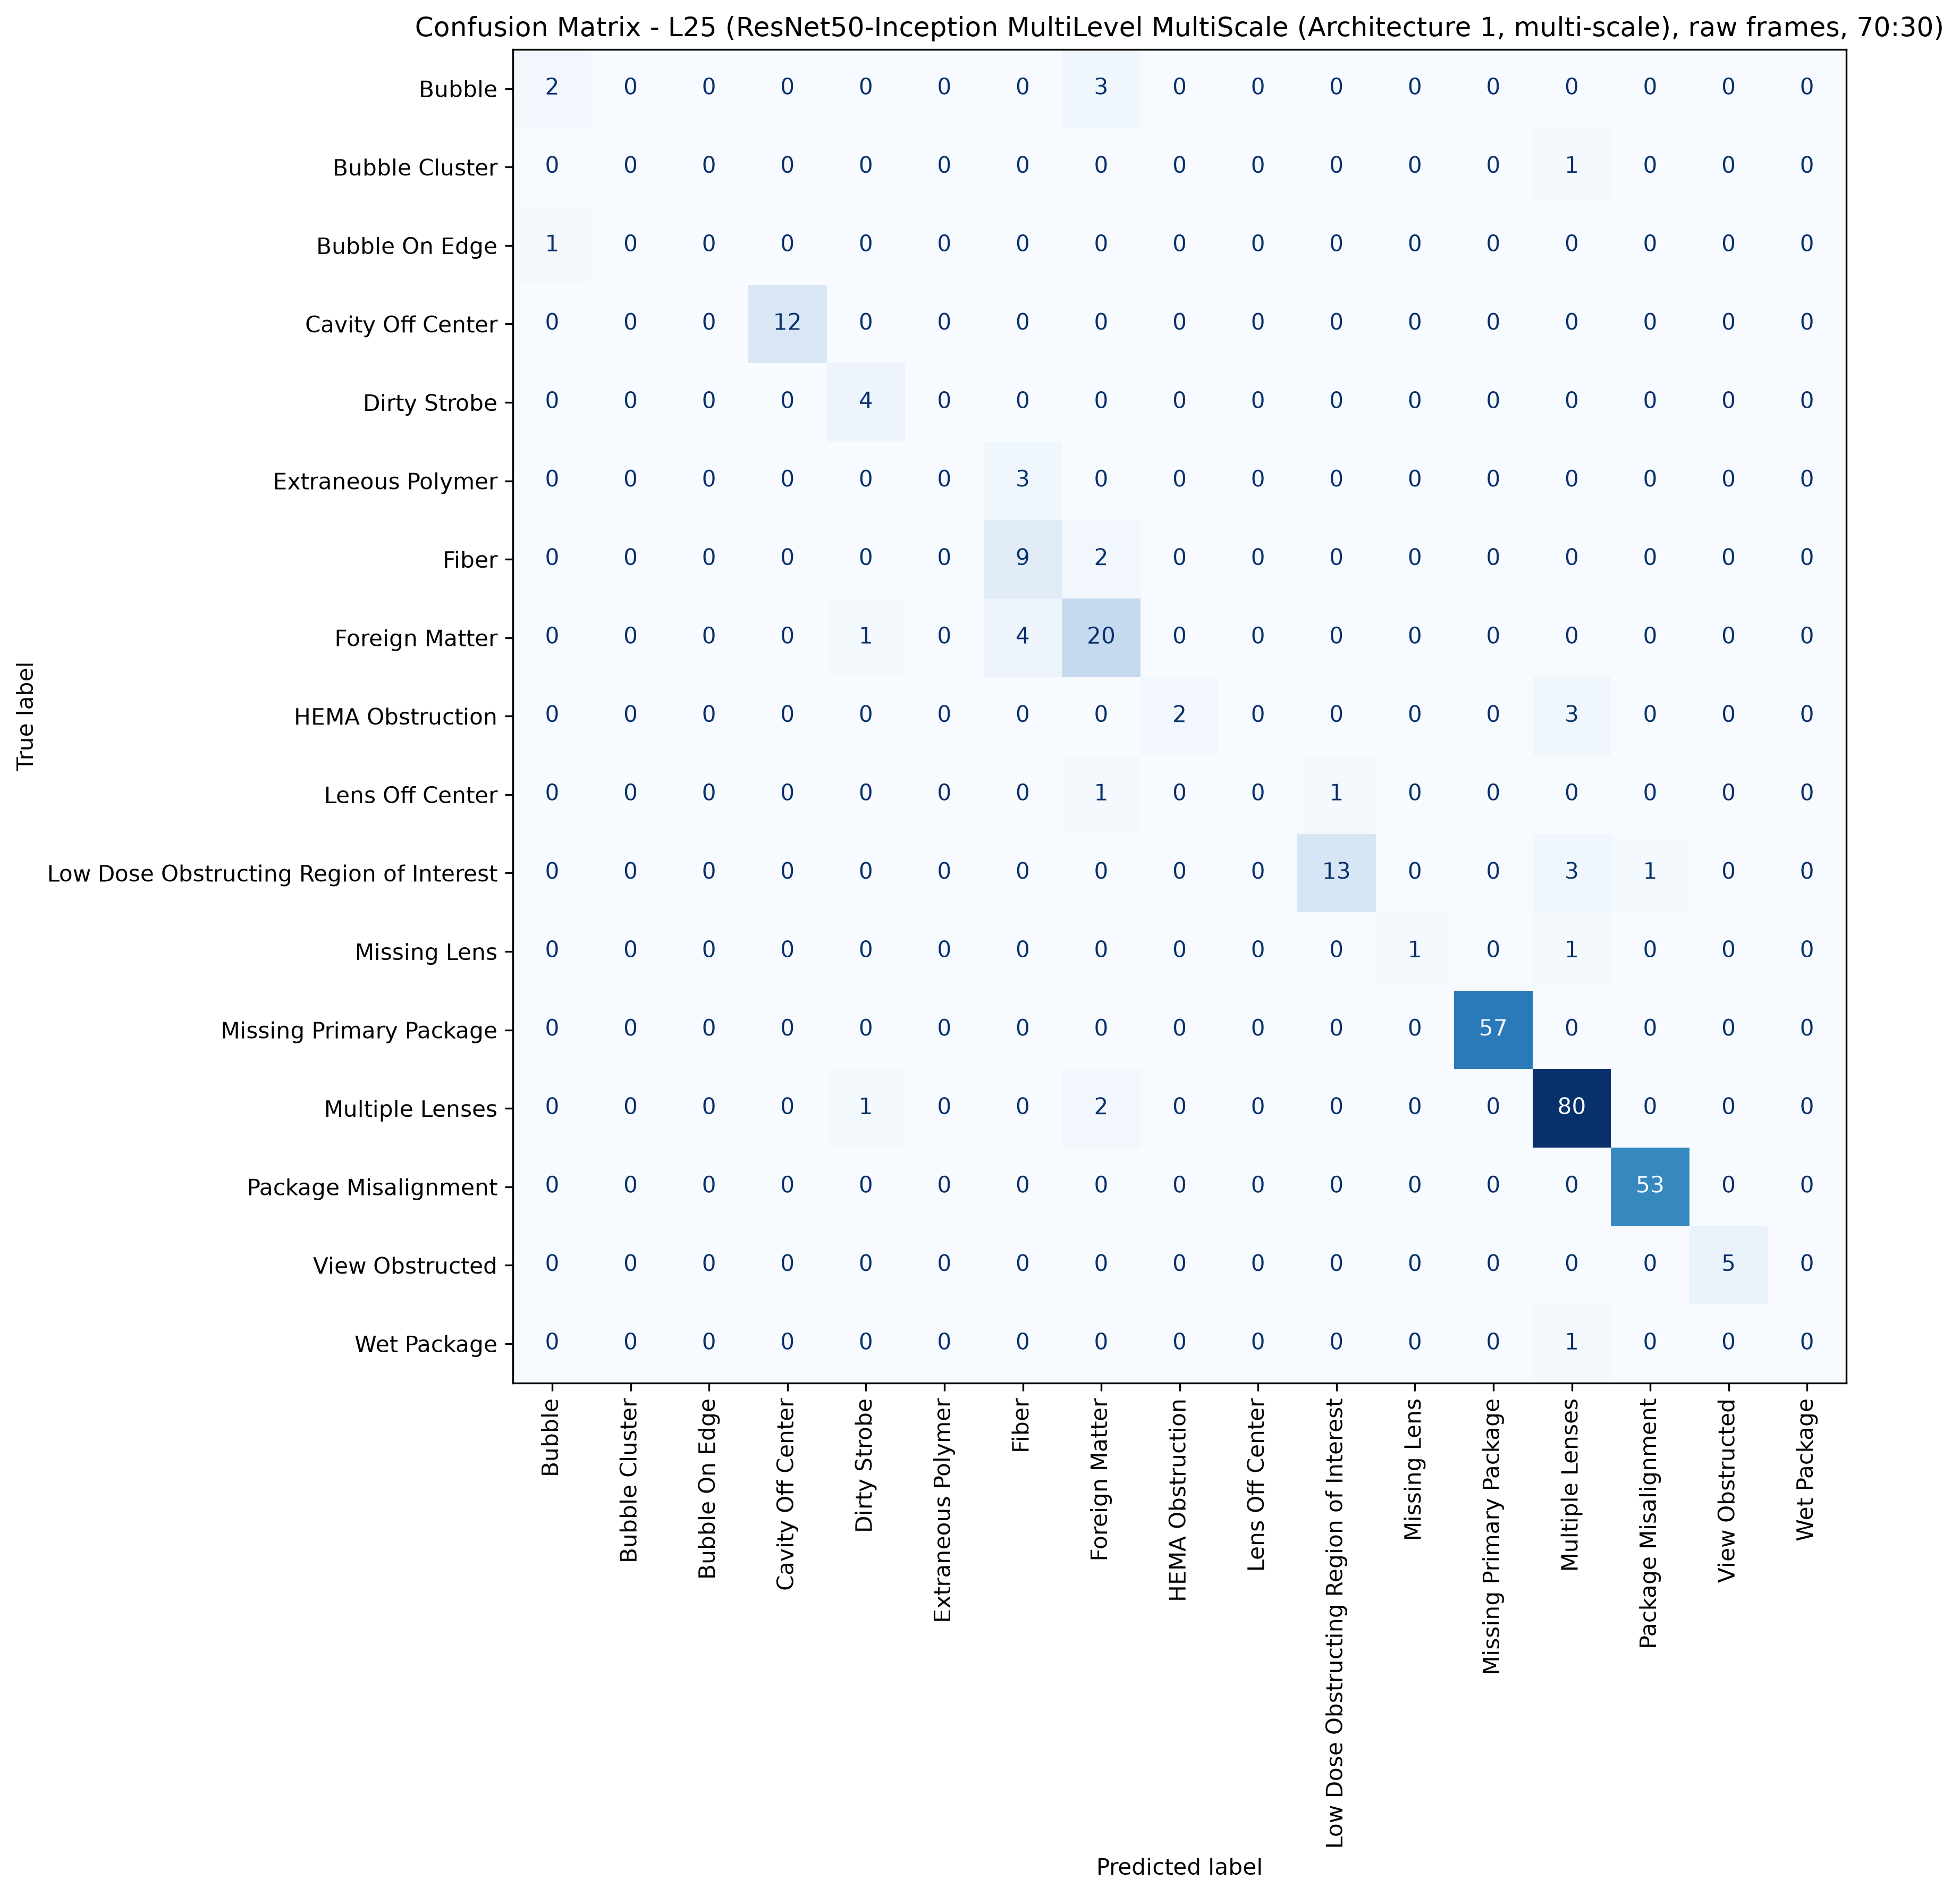


## L26

853 train / 365 test, 17 classes, accuracy 90.41%, macro F1 57.05%, weighted F1 88.82%, 8.9 minutes.

| Class | Test pictures | Precision | Recall | F1 |
|---|---|---|---|---|
| Bubble | 4 | 100.00% | 50.00% | 66.67% |
| Bubble Cluster | 1 | 0.00% | 0.00% | 0.00% |
| Bubble Irregular | 2 | 0.00% | 0.00% | 0.00% |
| Cavity Off Center | 7 | 87.50% | 100.00% | 93.33% |
| Dirty Strobe | 9 | 90.00% | 100.00% | 94.74% |
| Extraneous Polymer | 40 | 94.12% | 80.00% | 86.49% |
| Fiber | 8 | 66.67% | 25.00% | 36.36% |
| Foreign Matter | 49 | 75.00% | 97.96% | 84.96% |
| HEMA Obstruction | 1 | 0.00% | 0.00% | 0.00% |
| Lens Off Center | 2 | 0.00% | 0.00% | 0.00% |
| Low Dose Obstructing Region of Interest | 4 | 100.00% | 25.00% | 40.00% |
| Missing Lens | 1 | 0.00% | 0.00% | 0.00% |
| Missing Primary Package | 2 | 100.00% | 100.00% | 100.00% |
| Multiple Lenses | 202 | 93.90% | 99.01% | 96.39% |
| Package Misalignment | 7 | 100.00% | 85.71% | 92.31% |
| View Obstructed | 10 | 100.00% | 100.00% | 100.00% |
| Wet Package | 16 | 91.67% | 68.75% | 78.57% |


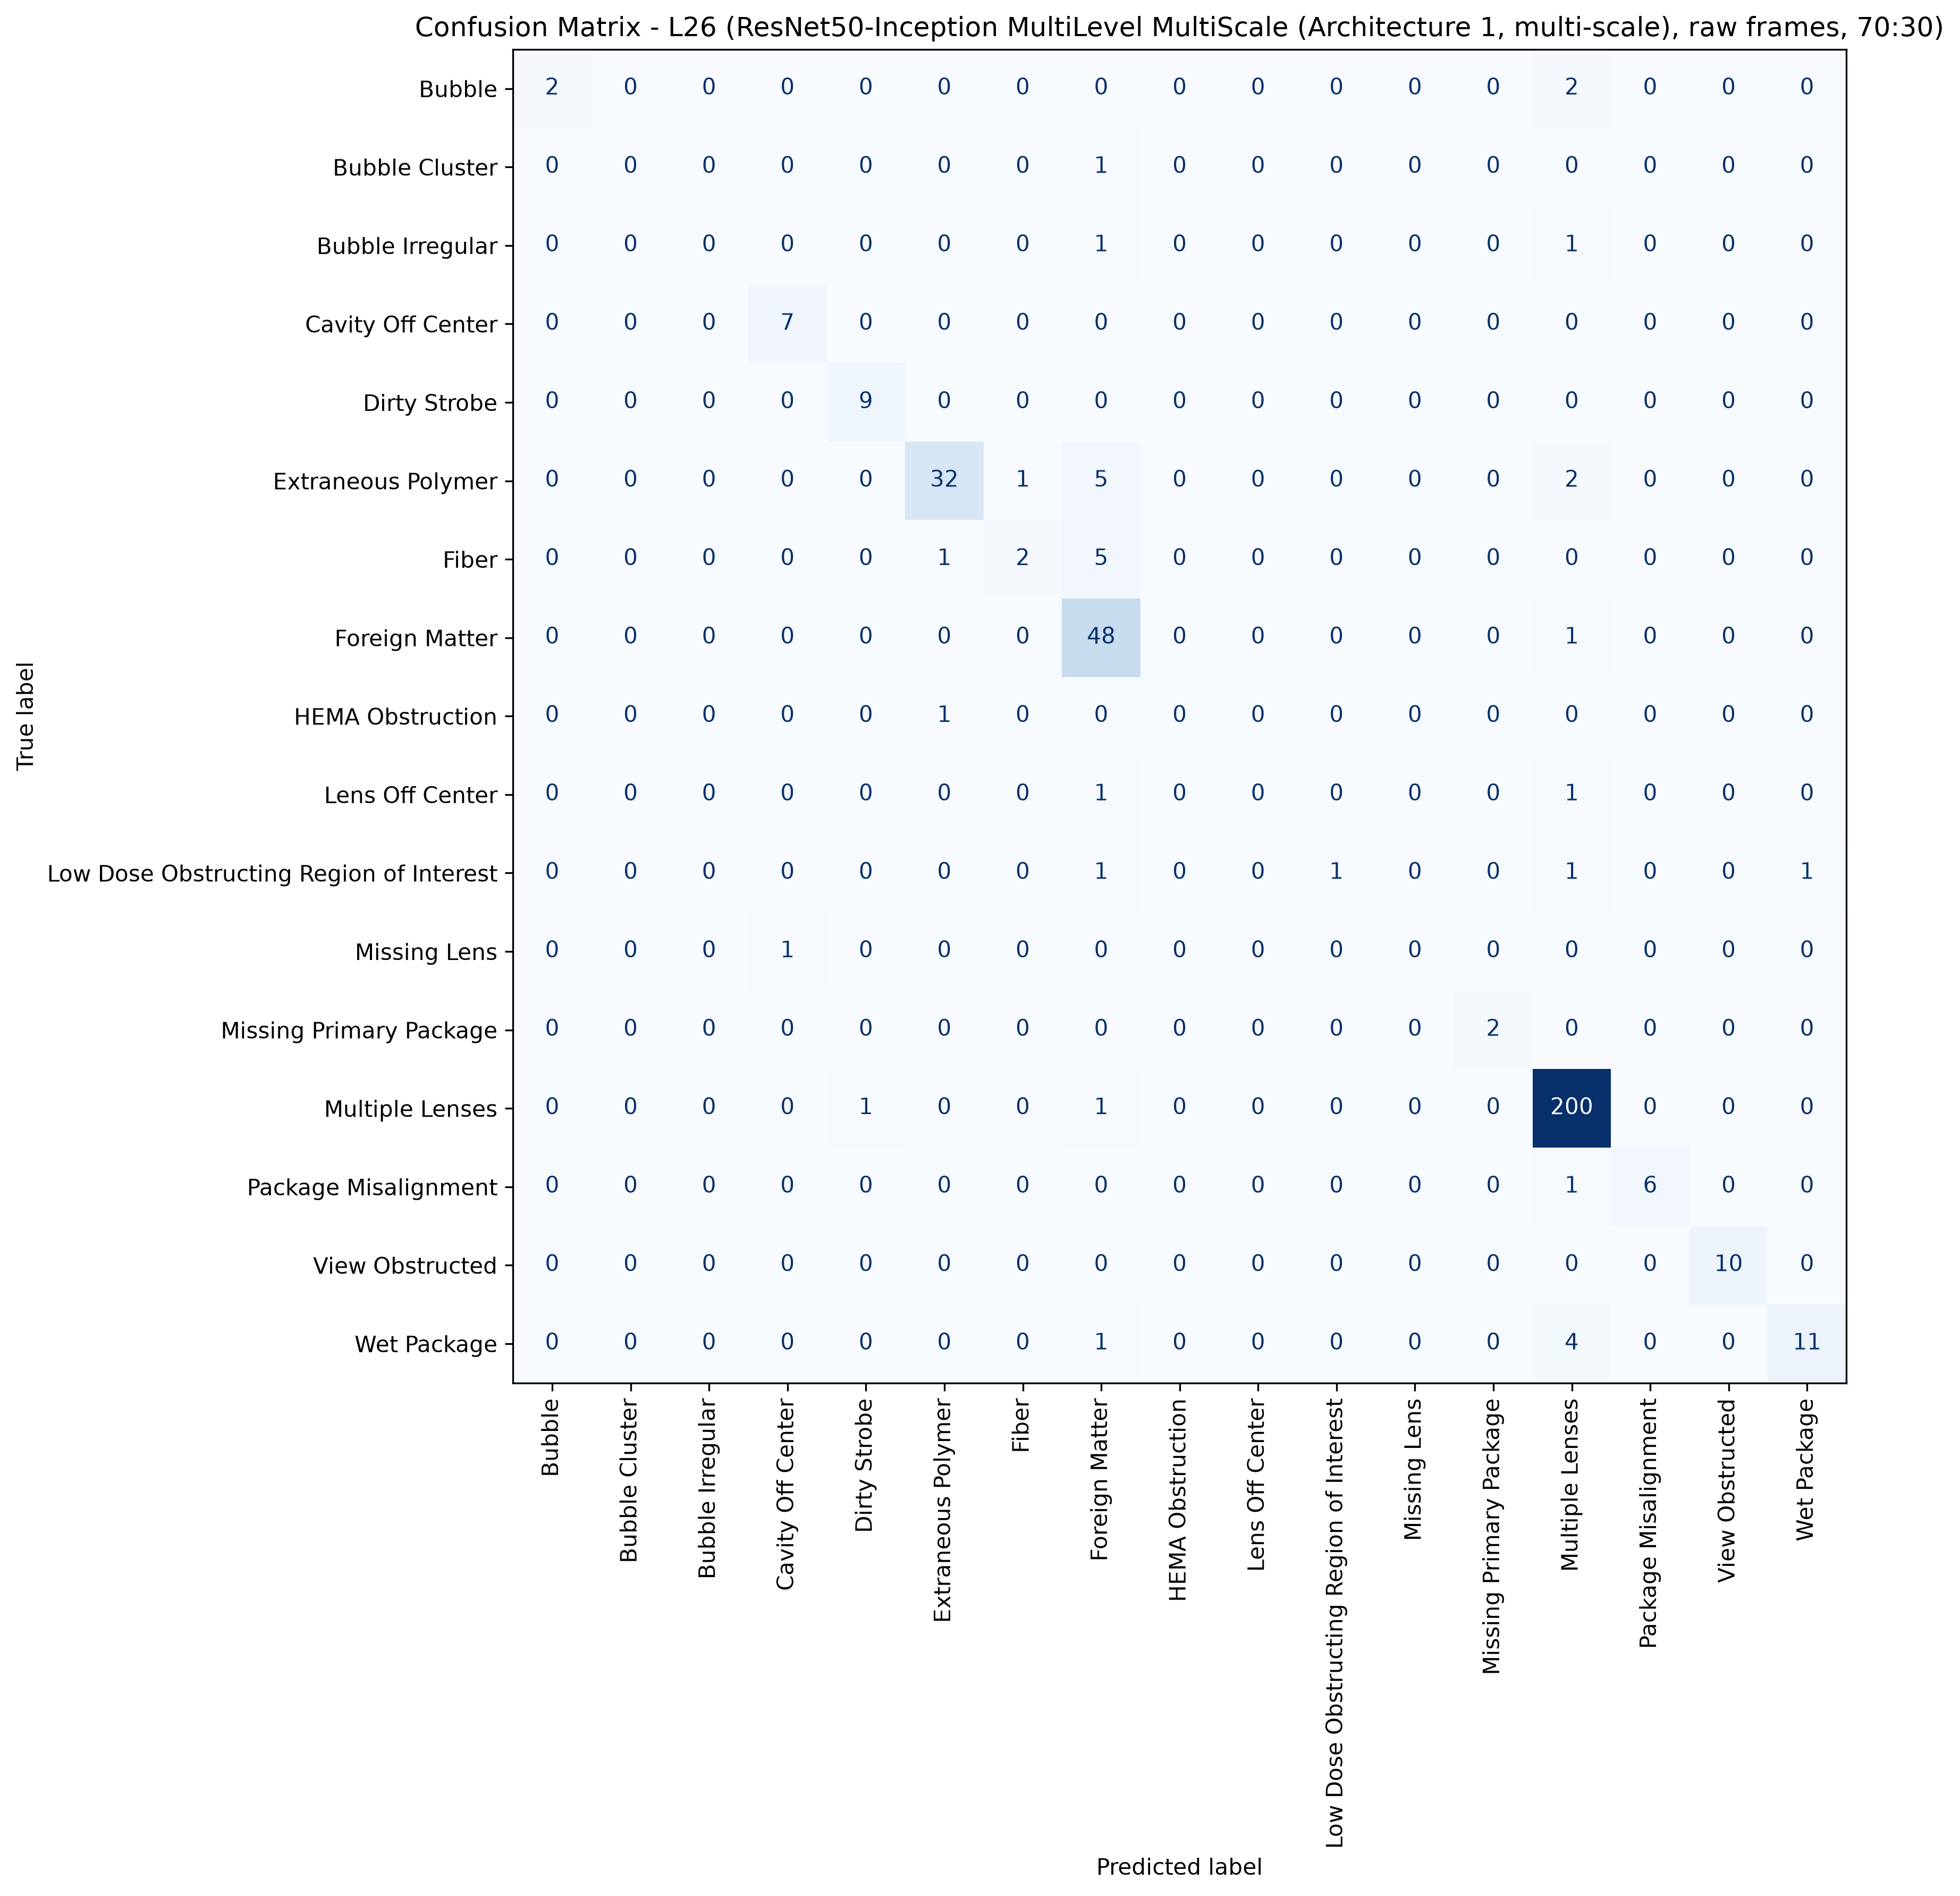


## L27

955 train / 409 test, 15 classes, accuracy 86.80%, macro F1 60.37%, weighted F1 86.11%, 10.0 minutes.

| Class | Test pictures | Precision | Recall | F1 |
|---|---|---|---|---|
| Bubble Cluster | 3 | 40.00% | 66.67% | 50.00% |
| Bubble Irregular | 6 | 50.00% | 33.33% | 40.00% |
| Bubble Scatter | 1 | 0.00% | 0.00% | 0.00% |
| Cavity Off Center | 4 | 80.00% | 100.00% | 88.89% |
| Extraneous Polymer | 5 | 14.29% | 20.00% | 16.67% |
| Fiber | 27 | 61.90% | 48.15% | 54.17% |
| Foreign Matter | 165 | 88.51% | 93.33% | 90.86% |
| HEMA Obstruction | 1 | 0.00% | 0.00% | 0.00% |
| Lens Off Center | 8 | 0.00% | 0.00% | 0.00% |
| Low Dose Obstructing Region of Interest | 139 | 94.29% | 94.96% | 94.62% |
| Missing Lens | 24 | 100.00% | 100.00% | 100.00% |
| Missing Primary Package | 4 | 100.00% | 100.00% | 100.00% |
| Multiple Lenses | 16 | 93.33% | 87.50% | 90.32% |
| Package Misalignment | 3 | 100.00% | 100.00% | 100.00% |
| View Obstructed | 3 | 100.00% | 66.67% | 80.00% |


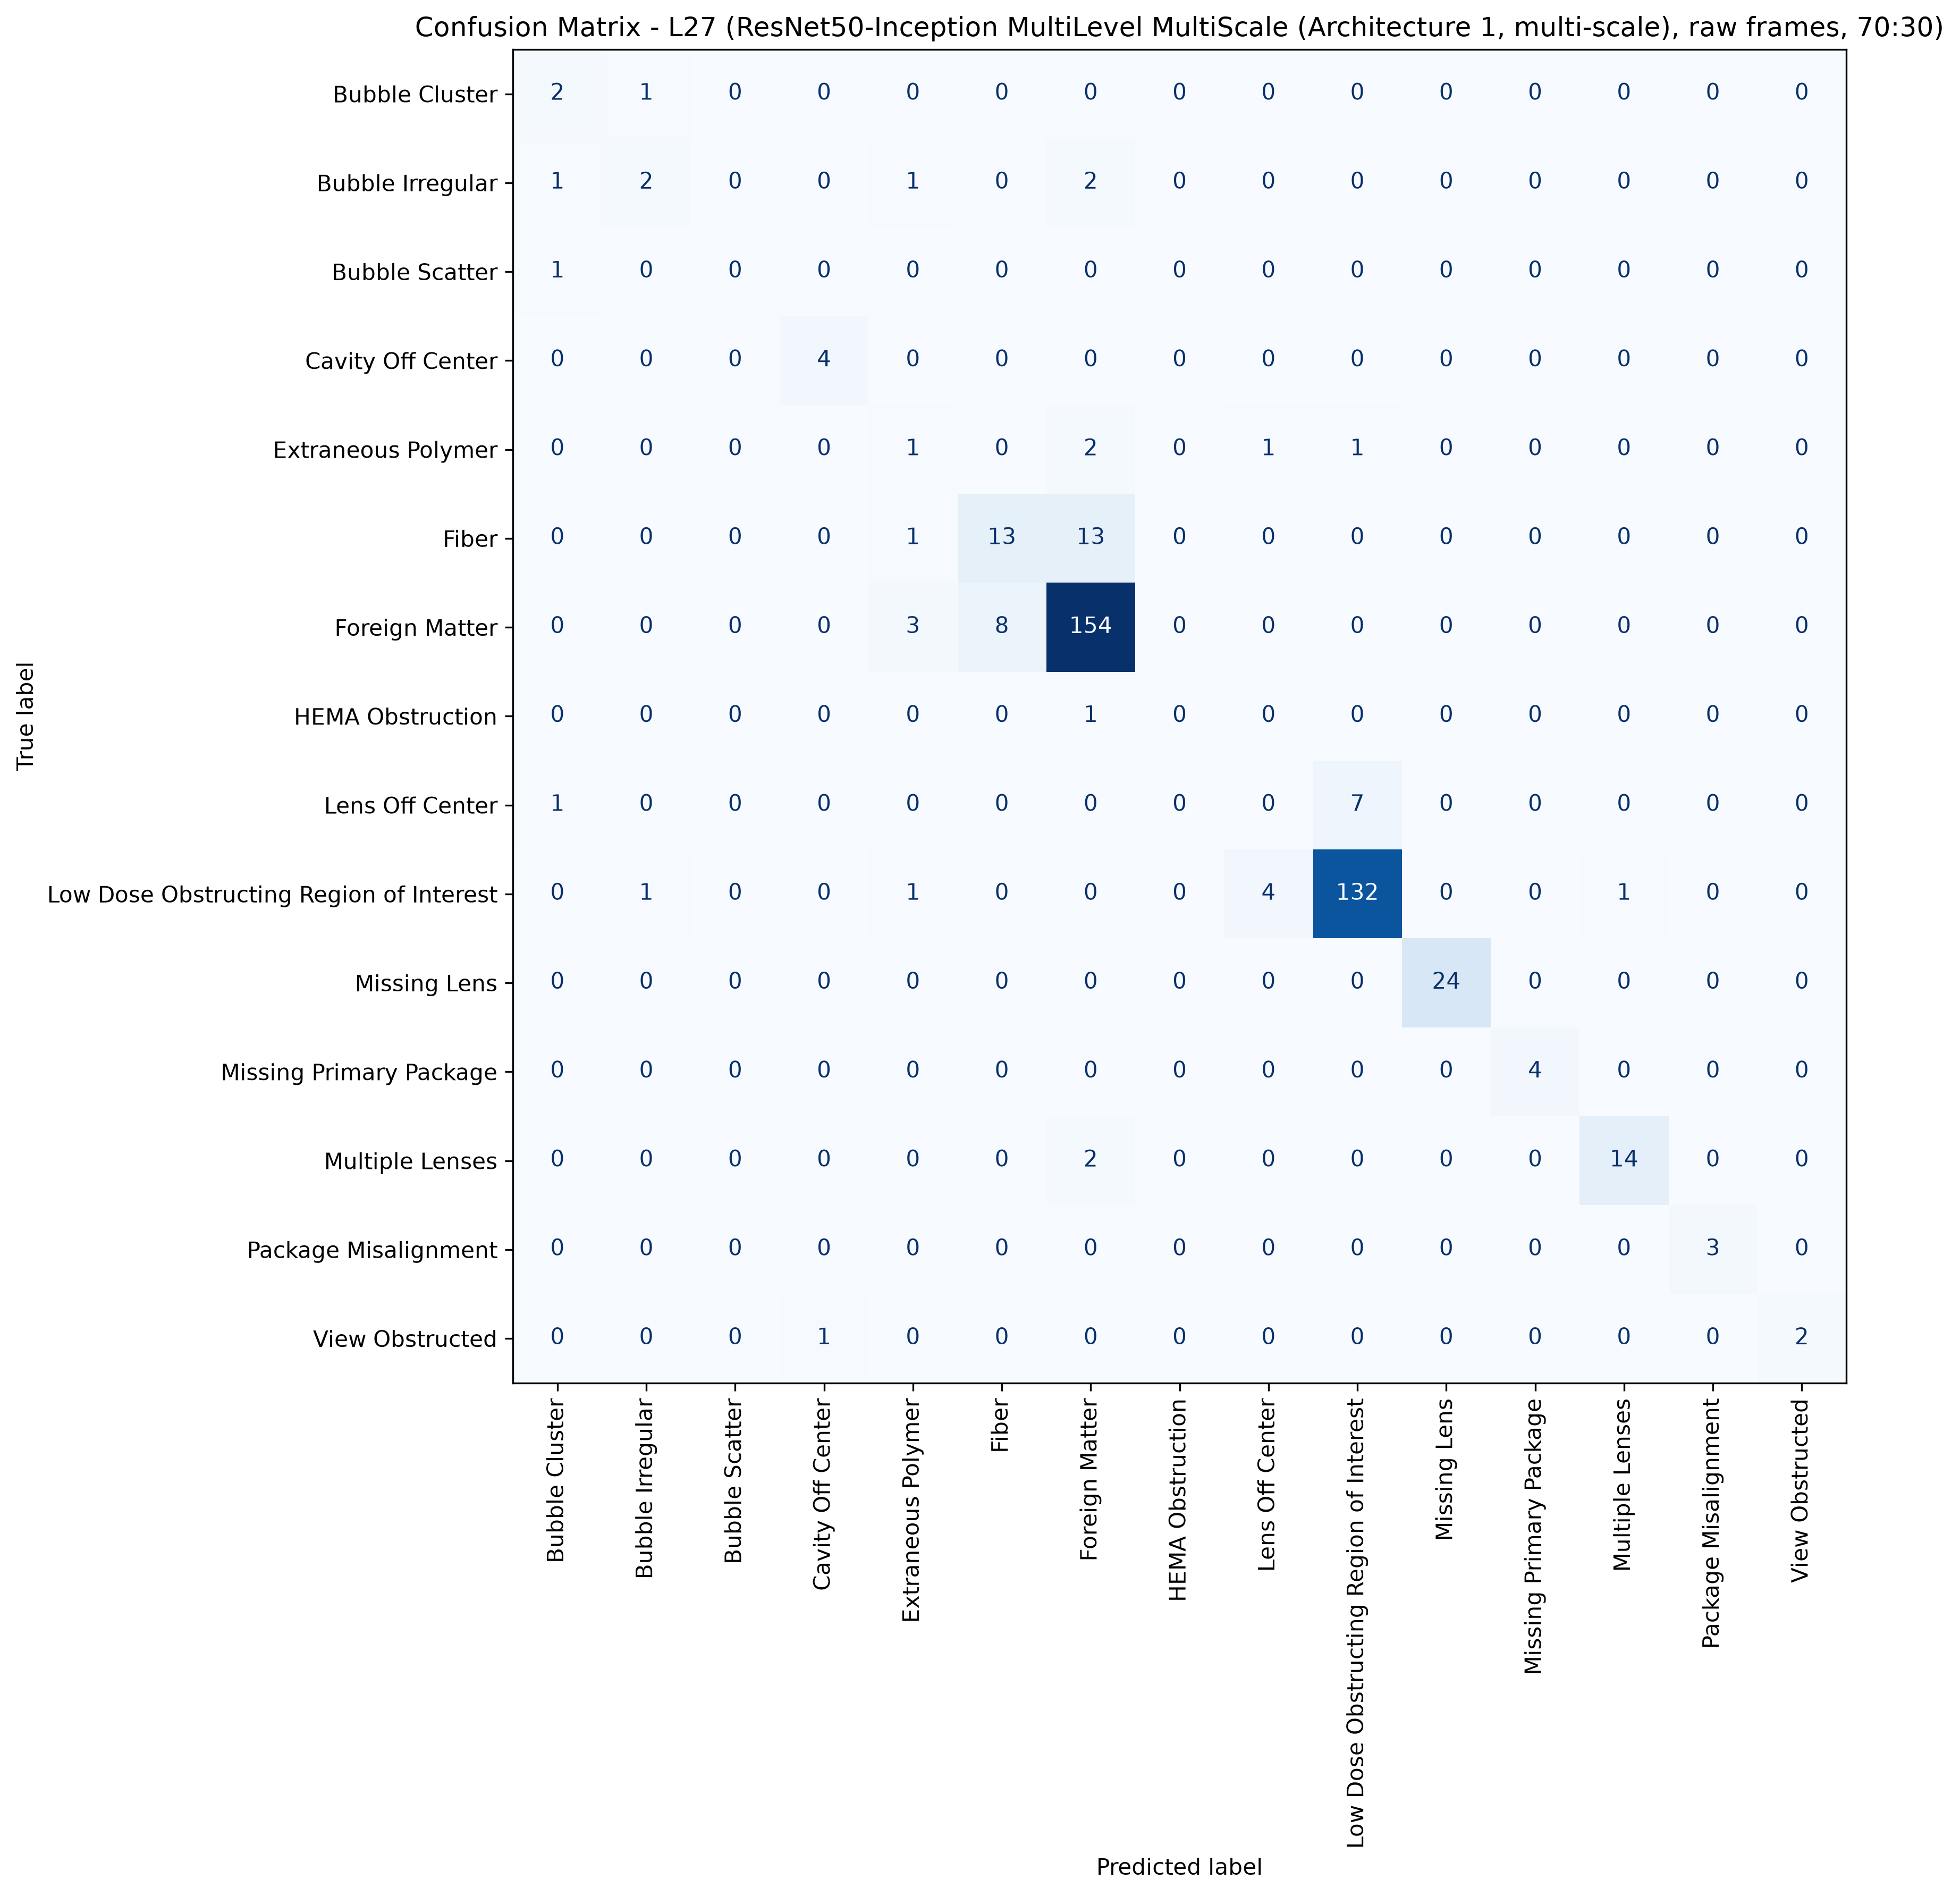


## L31

1411 train / 608 test, 19 classes, accuracy 90.62%, macro F1 45.62%, weighted F1 89.70%, 14.6 minutes.

| Class | Test pictures | Precision | Recall | F1 |
|---|---|---|---|---|
| Bubble Cluster | 1 | 0.00% | 0.00% | 0.00% |
| Bubble Irregular | 1 | 0.00% | 0.00% | 0.00% |
| Bubble On 123 | 4 | 0.00% | 0.00% | 0.00% |
| Bubble On Edge | 2 | 0.00% | 0.00% | 0.00% |
| Bubble Scatter | 1 | 0.00% | 0.00% | 0.00% |
| Cavity Off Center | 4 | 100.00% | 100.00% | 100.00% |
| Extraneous Polymer | 5 | 100.00% | 20.00% | 33.33% |
| Fiber | 36 | 53.97% | 94.44% | 68.69% |
| Foreign Matter | 59 | 77.78% | 59.32% | 67.31% |
| HEMA Fragment | 3 | 0.00% | 0.00% | 0.00% |
| HEMA Obstruction | 1 | 0.00% | 0.00% | 0.00% |
| Lens Off Center | 6 | 33.33% | 16.67% | 22.22% |
| Low Dose Obstructing Region of Interest | 392 | 97.98% | 99.23% | 98.61% |
| Missing Lens | 15 | 88.24% | 100.00% | 93.75% |
| Missing Primary Package | 22 | 100.00% | 100.00% | 100.00% |
| Multiple Lenses | 29 | 96.15% | 86.21% | 90.91% |
| Package Misalignment | 15 | 93.75% | 100.00% | 96.77% |
| View Obstructed | 11 | 100.00% | 90.91% | 95.24% |
| Wet Package | 1 | 0.00% | 0.00% | 0.00% |


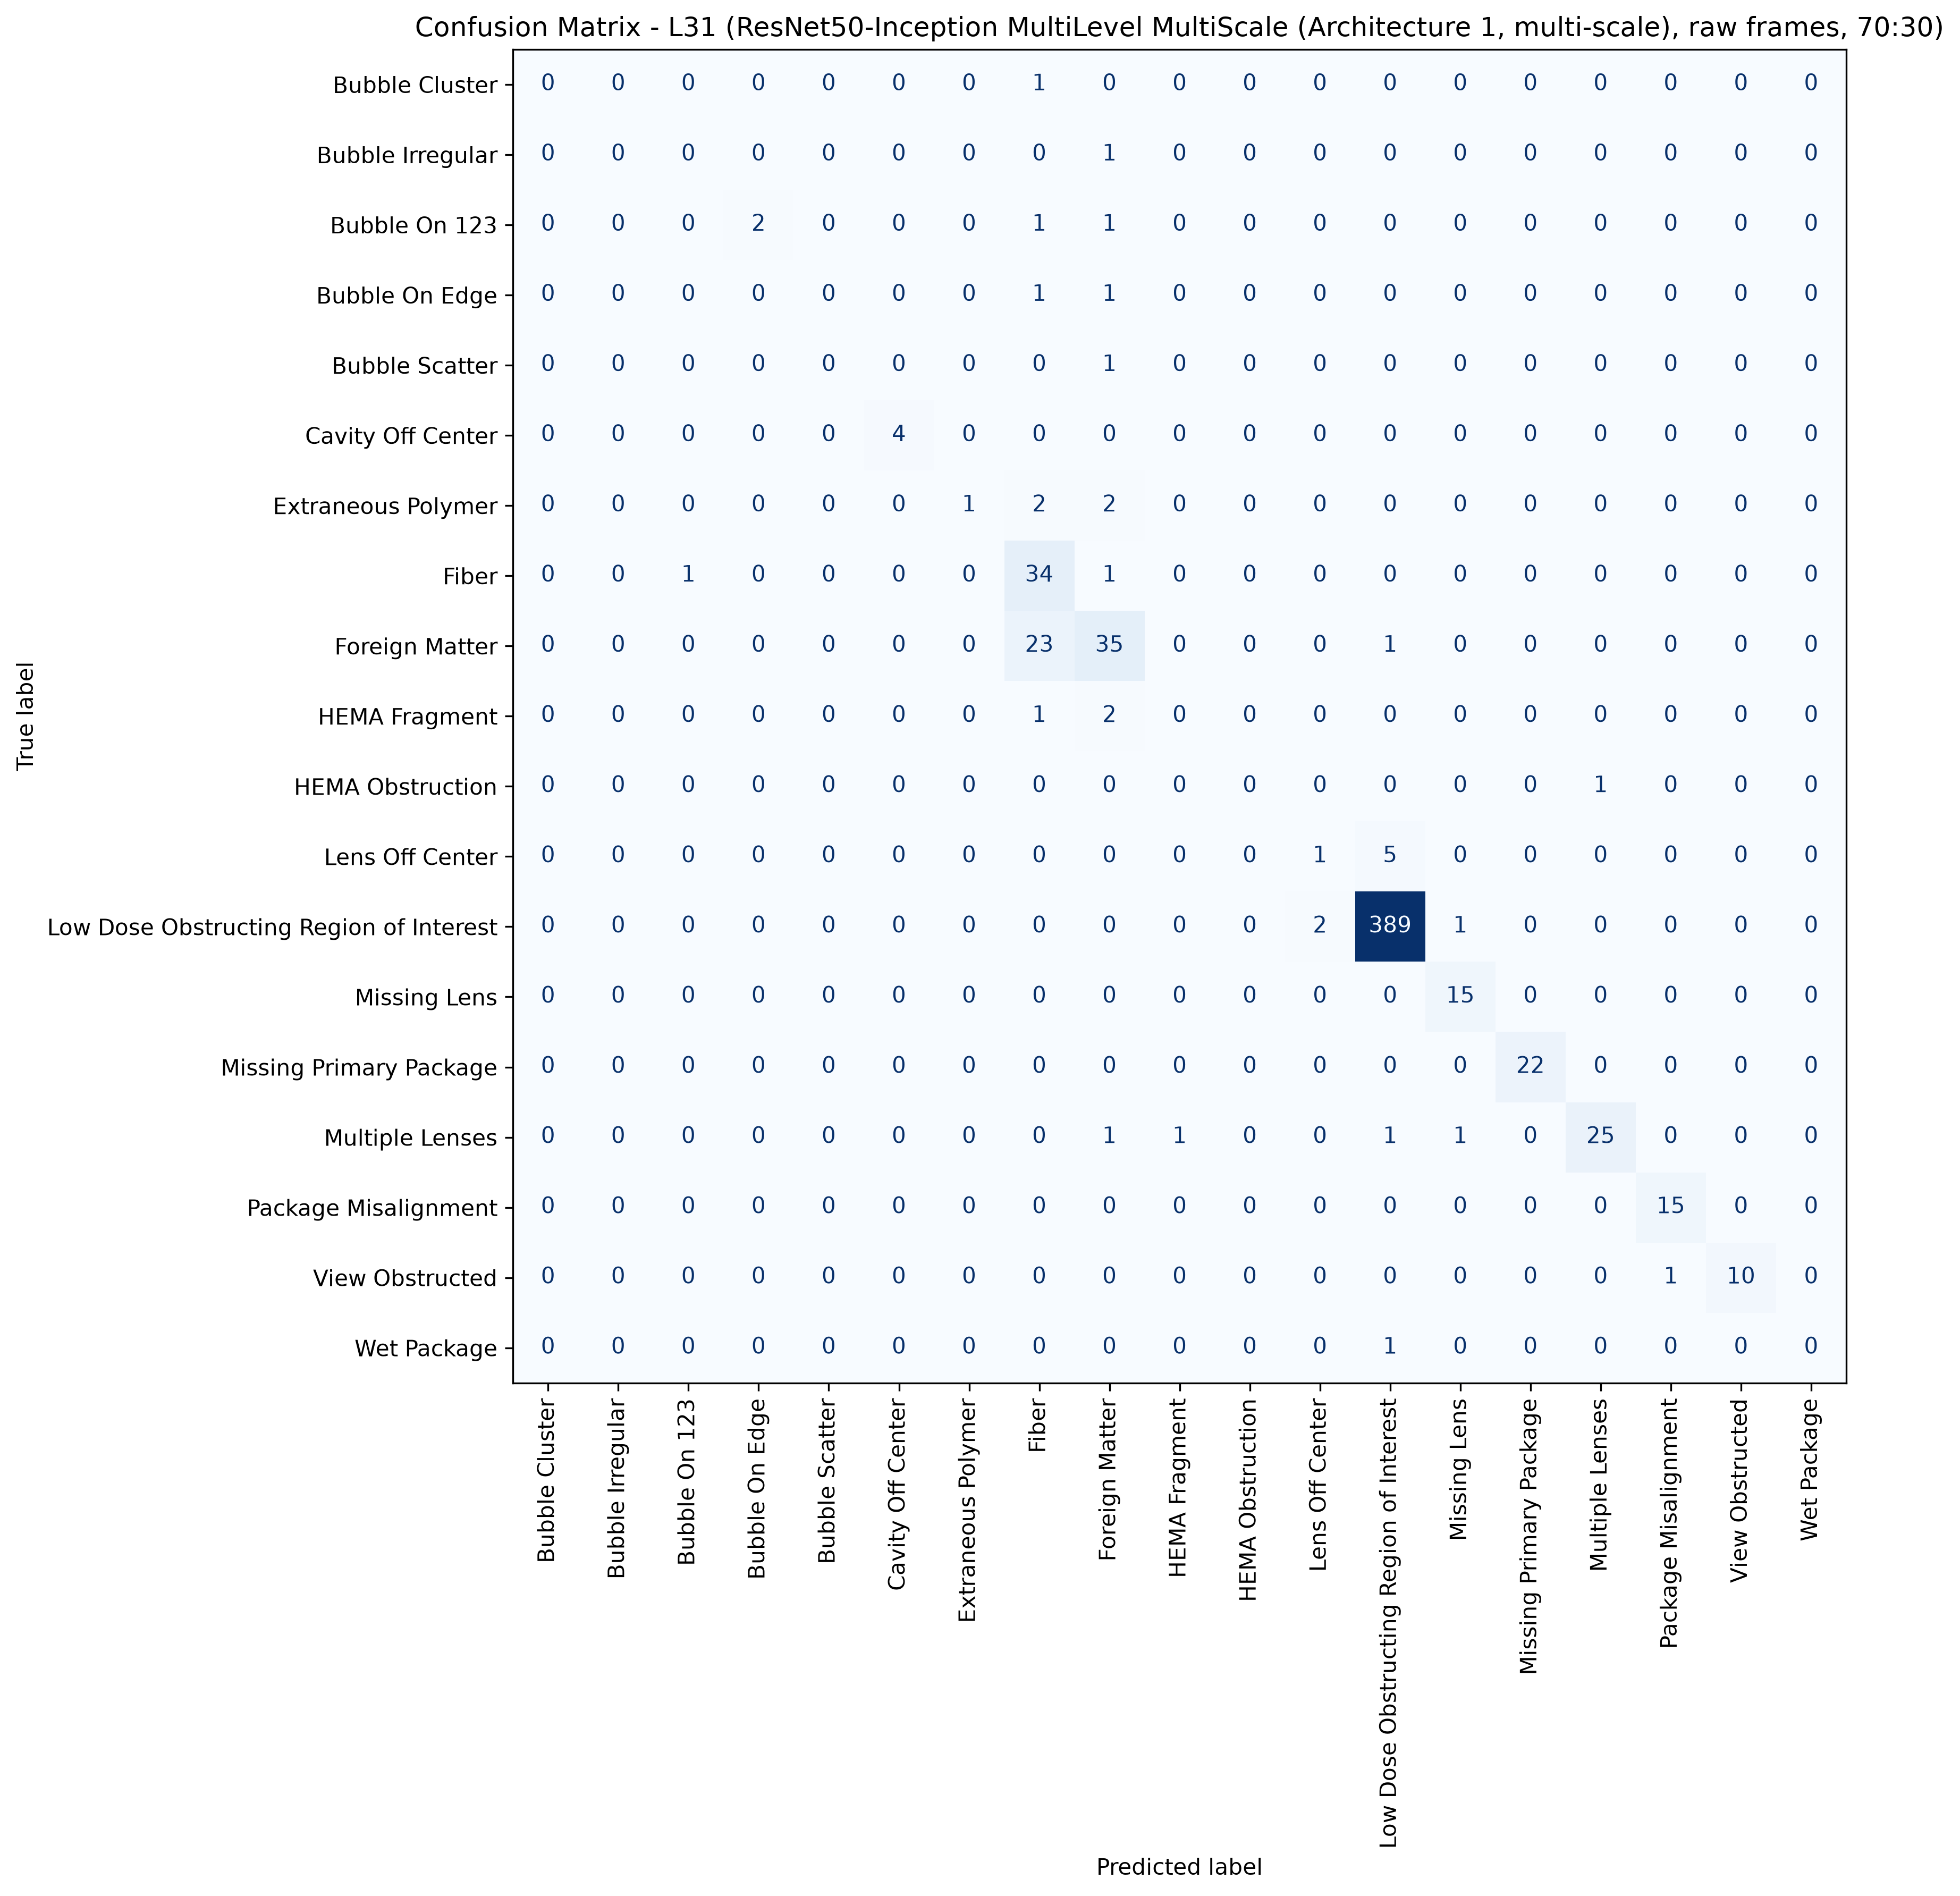


## Files

| Item | Where |
|---|---|
| This notebook | `notebooks/FMD_Line_Models_20260917.ipynb` |
| Results workbook | `reports/cnn/FMD_Line_ResNet50_Results_20260917.xlsx` |
| Split assignments | `run/line_splits_20260917/line_<line>/split.csv` |
| Per-run outputs | `runs/cnn/lines/<line>/epochs_50/` (metrics, confusion matrix, history, log) |
| Trained weights | on the VM only: `~/line_experiment_20260917/runs/<line>/epochs_50/weights.weights.h5` |
| Trainer | `experiments/cnn/train_line_model.py` |
| Split builder | `src/build_line_split_assignments.py` |
